# PHI NER — Entity-Level Evaluation

This notebook provides a rigorous academic evaluation of the fine-tuned NER models.

**What it does:**
1. **Entity-level metrics** (seqeval strict matching) — token-level F1 can be misleading; a partial name match ("Adah626" without "Klein929") counts as a miss at entity level
2. **5-fold cross-validation** — proves results aren't dependent on one lucky train/val split
3. **Multi-seed runs** — proves results aren't dependent on random weight initialization
4. **Statistical significance** — Wilcoxon test to determine if model differences are real or noise
5. **Latency profiling** — P50/P95/P99 inference times, throughput, latency vs text length

**Runtime**: GPU (T4) — Go to Runtime > Change runtime type > GPU

**Estimated time**: ~4 to 5 hours (early stopping + optimized batch sizes)

In [1]:
# Start Time
import time
start_time = time.time()

In [2]:
!pip install -q transformers torch wandb weave seqeval accelerate scikit-learn matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.9/52.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 61.9 MB/s eta 0:00:00


In [3]:
import wandb
import weave
from google.colab import userdata

try:
    wandb.login(key=userdata.get("WANDB_API_KEY"))
    print("Logged in via Colab secrets")
except Exception:
    wandb.login()

WANDB_PROJECT = "mobile-rag-firewall"
weave.init(WANDB_PROJECT)

import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ricardo-morales-b to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in via Colab secrets


weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


GPU available: True
GPU: Tesla T4


In [4]:
import json, time, numpy as np
from pathlib import Path
from torch.utils.data import Dataset as TorchDataset
from transformers import (AutoModelForTokenClassification, AutoTokenizer, Trainer,
                          TrainingArguments, DataCollatorForTokenClassification,
                          EarlyStoppingCallback, pipeline as hf_pipeline)
from sklearn.model_selection import KFold
from seqeval.metrics import classification_report, f1_score
from seqeval.scheme import IOB2
import matplotlib.pyplot as plt

LABEL_LIST = ["O", "B-NAME", "I-NAME", "B-ADDRESS", "I-ADDRESS"]
LABEL_TO_ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID_TO_LABEL = {i: l for l, i in LABEL_TO_ID.items()}

MODEL_CONFIGS = {
    "distilbert": "distilbert-base-uncased",
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
}

# Batch sizes optimized for T4 16GB with FP16
BATCH_SIZES = {"distilbert": 32, "bert": 24, "roberta": 24}

# Load data from Weave
train_ds = weave.ref("phi-ner-train:latest").get()
val_ds = weave.ref("phi-ner-val:latest").get()
test_ds = weave.ref("phi-ner-test:latest").get()
train_data, val_data, test_data = train_ds.rows, val_ds.rows, test_ds.rows
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 8682, Val: 1861, Test: 1861


In [5]:
class PHINERDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data, self.tokenizer, self.max_length = data, tokenizer, max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        tokens, ner_tags = self.data[idx]["tokens"], self.data[idx]["ner_tags"]
        enc = self.tokenizer(tokens, is_split_into_words=True, truncation=True,
                             max_length=self.max_length, padding=False)
        word_ids = enc.word_ids()
        labels, prev = [], None
        for wid in word_ids:
            if wid is None: labels.append(-100)
            elif wid != prev:
                labels.append(LABEL_TO_ID.get(ner_tags[wid] if wid < len(ner_tags) else "O", 0))
            else:
                tag = ner_tags[wid] if wid < len(ner_tags) else "O"
                if tag.startswith("B-"): labels.append(LABEL_TO_ID.get("I-" + tag[2:], 0))
                elif tag.startswith("I-"): labels.append(LABEL_TO_ID.get(tag, 0))
                else: labels.append(-100)
            prev = wid
        enc["labels"] = labels
        return {k: torch.tensor(v) for k, v in enc.items()}

def compute_metrics_seqeval(eval_pred):
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=-1)
    true_seqs, pred_seqs = [], []
    for pred_seq, label_seq in zip(preds, labels):
        t, p = [], []
        for pr, la in zip(pred_seq, label_seq):
            if la != -100:
                t.append(ID_TO_LABEL[la])
                p.append(ID_TO_LABEL[pr])
        true_seqs.append(t)
        pred_seqs.append(p)
    f1 = f1_score(true_seqs, pred_seqs, mode='strict', scheme=IOB2)
    return {"f1_entity": f1}

print("Dataset class and seqeval metrics ready.")

Dataset class and seqeval metrics ready.


## Entity-Level Evaluation with seqeval

Token-level F1 (from notebook 01) scores each token independently. But for a firewall, we need **entity-level** evaluation — the entire name or address span must be correct.

Example:
```
True:    "Adah626 Flo729 Klein929"  (3 tokens, 1 entity)
Pred:    "Adah626 Flo729"           (2 tokens matched)
Token F1: 2/3 = 67%                 (looks ok)
Entity F1: 0/1 = 0%                 (entity missed — name still leaks!)
```

We use `seqeval` with `mode='strict'` — the predicted span must exactly match the true span to count as correct.

The cell below defines `train_and_evaluate()` which trains a model from scratch and evaluates on the test set with seqeval.

In [6]:
import glob

def train_and_evaluate(model_key, model_name, train_data, val_data, test_data,
                       lr=5e-5, epochs=5, batch_size=None, seed=42, run_name=None):
    """Train a model and return entity-level seqeval results on test set."""
    if batch_size is None:
        batch_size = BATCH_SIZES.get(model_key, 24)
    output_dir = f"models/{model_key}_{seed}"
    best_dir = f"{output_dir}/best"
    if run_name is None:
        run_name = f"eval-{model_key}-s{seed}"

    torch.manual_seed(seed)
    wandb.init(project=WANDB_PROJECT, name=run_name,
               config={"model": model_name, "seed": seed, "lr": lr, "epochs": epochs},
               tags=["evaluation", model_key], reinit=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=len(LABEL_LIST), id2label=ID_TO_LABEL, label2id=LABEL_TO_ID)

    train_ds = PHINERDataset(train_data, tokenizer)
    val_ds = PHINERDataset(val_data, tokenizer)
    test_ds_torch = PHINERDataset(test_data, tokenizer)

    args = TrainingArguments(
        output_dir=output_dir, run_name=run_name, report_to="wandb",
        num_train_epochs=epochs, per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size, learning_rate=lr,
        weight_decay=0.01, eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="f1_entity",
        greater_is_better=True, save_total_limit=1, logging_steps=100,
        fp16=torch.cuda.is_available(), seed=seed,
        dataloader_num_workers=2, dataloader_pin_memory=True)

    trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                      eval_dataset=val_ds,
                      data_collator=DataCollatorForTokenClassification(tokenizer),
                      compute_metrics=compute_metrics_seqeval,
                      callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    trainer.train()

    # Save best model to a known path (load_best_model_at_end ensures best is loaded)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)

    # Entity-level eval on test set
    preds_out = trainer.predict(test_ds_torch)
    preds = np.argmax(preds_out.predictions, axis=-1)
    labels = preds_out.label_ids

    true_seqs, pred_seqs = [], []
    for pred_seq, label_seq in zip(preds, labels):
        t, p = [], []
        for pr, la in zip(pred_seq, label_seq):
            if la != -100:
                t.append(ID_TO_LABEL[la])
                p.append(ID_TO_LABEL[pr])
        true_seqs.append(t)
        pred_seqs.append(p)

    report = classification_report(true_seqs, pred_seqs, output_dict=True, mode='strict', scheme=IOB2)
    print(classification_report(true_seqs, pred_seqs, mode='strict', scheme=IOB2))

    wandb.log({"test/seqeval_report": report})
    wandb.finish()
    return report, trainer

print("Training function ready.")

Training function ready.


In [7]:
# Train and evaluate all 3 models with entity-level metrics
all_reports = {}
for model_key, model_name in MODEL_CONFIGS.items():
    print(f"\n{'='*60}\n  Training: {model_key}\n{'='*60}")
    lr = {"distilbert": 5e-5, "bert": 3e-5, "roberta": 2e-5}[model_key]
    report, _ = train_and_evaluate(model_key, model_name, train_data, val_data, test_data, lr=lr)
    all_reports[model_key] = report

# Print comparison
print(f"\n{'='*60}\n  ENTITY-LEVEL COMPARISON (seqeval strict)\n{'='*60}")
print(f"  {'Model':<15} {'F1 NAME':>10} {'F1 ADDR':>10} {'F1 macro':>10}")
print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10}")
for mk, r in all_reports.items():
    f1_n = r.get("NAME", {}).get("f1-score", 0)
    f1_a = r.get("ADDRESS", {}).get("f1-score", 0)
    f1_m = r.get("macro avg", {}).get("f1-score", 0)
    print(f"  {mk:<15} {f1_n:>10.4f} {f1_a:>10.4f} {f1_m:>10.4f}")


  Training: distilbert


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     ADDRESS       0.96      0.97      0.96       771
        NAME       1.00      1.00      1.00       502

   micro avg       0.98      0.98      0.98      1273
   macro avg       0.98      0.98      0.98      1273
weighted avg       0.98      0.98      0.98      1273



eval/f1_entity,▁▂▆██
eval/loss,█▃▁▁▂
eval/runtime,▃▂▁█▃
eval/samples_per_second,▆▇█▁▆
eval/steps_per_second,▆▇█▁▆
test/f1_entity,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...



  ENTITY-LEVEL COMPARISON (seqeval strict)
  Model              F1 NAME    F1 ADDR   F1 macro
  --------------- ---------- ---------- ----------
  distilbert          1.0000     0.9594     0.9797
  bert                1.0000     0.9593     0.9797
  roberta             1.0000     0.9644     0.9822


## 5-Fold Cross-Validation

A single train/val split might produce optimistic or pessimistic results depending on which examples land in which set. Cross-validation addresses this by:

1. Combining train + val data
2. Splitting into 5 equal folds
3. Training 5 times — each fold takes a turn as validation
4. Reporting mean ± standard deviation

If std is low (~0.001), the model is stable. If std is high (~0.05+), the results depend on the split and shouldn't be trusted.

Each fold is logged as a separate W&B run for tracking.

In [8]:
def cross_validate(model_key, model_name, data, test_data, k=5, lr=5e-5, epochs=5, seed=42):
    """Run k-fold cross-validation, return per-fold entity-level F1."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data)):
        print(f"  Fold {fold+1}/{k}...")
        fold_train = [data[i] for i in train_idx]
        fold_val = [data[i] for i in val_idx]

        report, _ = train_and_evaluate(
            model_key, model_name, fold_train, fold_val, test_data,
            lr=lr, epochs=epochs, seed=seed+fold,
            run_name=f"cv-{model_key}-fold{fold+1}")
        fold_results.append(report)

    # Aggregate
    metrics = {}
    for entity in ["NAME", "ADDRESS", "macro avg"]:
        f1s = [r.get(entity, {}).get("f1-score", 0) for r in fold_results]
        metrics[entity] = {"mean": np.mean(f1s), "std": np.std(f1s)}

    return metrics, fold_results

# Run CV for all models
combined_data = list(train_data) + list(val_data)
cv_results = {}
for model_key, model_name in MODEL_CONFIGS.items():
    print(f"\n{'='*60}\n  Cross-validation: {model_key}\n{'='*60}")
    lr = {"distilbert": 5e-5, "bert": 3e-5, "roberta": 2e-5}[model_key]
    metrics, _ = cross_validate(model_key, model_name, combined_data, test_data, lr=lr, epochs=5)
    cv_results[model_key] = metrics

# Print comparison
print(f"\n{'='*60}\n  CROSS-VALIDATION RESULTS (5-fold, entity-level F1)\n{'='*60}")
print(f"  {'Model':<15} {'NAME':>15} {'ADDRESS':>15} {'Macro':>15}")
print(f"  {'-'*15} {'-'*15} {'-'*15} {'-'*15}")
for mk, m in cv_results.items():
    n = f"{m['NAME']['mean']:.4f}±{m['NAME']['std']:.4f}"
    a = f"{m['ADDRESS']['mean']:.4f}±{m['ADDRESS']['std']:.4f}"
    ma = f"{m['macro avg']['mean']:.4f}±{m['macro avg']['std']:.4f}"
    print(f"  {mk:<15} {n:>15} {a:>15} {ma:>15}")


  Cross-validation: distilbert
  Fold 1/5...


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     ADDRESS       0.96      0.99      0.98       771
        NAME       1.00      1.00      1.00       502

   micro avg       0.98      0.99      0.98      1273
   macro avg       0.98      1.00      0.99      1273
weighted avg       0.98      0.99      0.98      1273



eval/f1_entity,▁▆█▅█
eval/loss,█▃▁▂▁
eval/runtime,▃▁█▄█
eval/samples_per_second,▆█▁▅▁
eval/steps_per_second,▆█▁▅▁
test/f1_entity,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...



  CROSS-VALIDATION RESULTS (5-fold, entity-level F1)
  Model                      NAME         ADDRESS           Macro
  --------------- --------------- --------------- ---------------
  distilbert        0.9998±0.0004   0.9657±0.0084   0.9827±0.0043
  bert              0.9992±0.0012   0.9644±0.0092   0.9818±0.0051
  roberta           0.9994±0.0005   0.9694±0.0040   0.9844±0.0019


## Multi-Seed + Statistical Significance

Even with the same data split, different random seeds produce different weight initializations, leading to slightly different results. We train each model 3 times with seeds 42, 123, 456 and report mean ± std.

Then we run a **Wilcoxon signed-rank test** between the top two models. If p < 0.05, the difference is statistically significant — one model is genuinely better. If p > 0.05, the difference is likely noise and both models are equivalent.

In [9]:
# Train each model 3x with different seeds
SEEDS = [42, 123, 456]
seed_results = {}

for model_key, model_name in MODEL_CONFIGS.items():
    lr = {"distilbert": 5e-5, "bert": 3e-5, "roberta": 2e-5}[model_key]
    reports = []
    for seed in SEEDS:
        print(f"\n  {model_key} seed={seed}...")
        report, _ = train_and_evaluate(model_key, model_name, train_data, val_data, test_data,
                                       lr=lr, epochs=5, seed=seed,
                                       run_name=f"seed-{model_key}-s{seed}")
        reports.append(report)
    macro_f1s = [r.get("macro avg", {}).get("f1-score", 0) for r in reports]
    seed_results[model_key] = {"mean": np.mean(macro_f1s), "std": np.std(macro_f1s), "f1s": macro_f1s}

print(f"\n{'='*60}\n  MULTI-SEED RESULTS (F1 macro, entity-level)\n{'='*60}")
for mk, r in seed_results.items():
    print(f"  {mk:<15} {r['mean']:.4f} ± {r['std']:.4f}  ({r['f1s']})")

# McNemar's test between top 2 models
sorted_models = sorted(seed_results.items(), key=lambda x: -x[1]["mean"])
m1, m2 = sorted_models[0][0], sorted_models[1][0]
from scipy.stats import wilcoxon
stat, pval = wilcoxon(seed_results[m1]["f1s"], seed_results[m2]["f1s"])
print(f"\n  Wilcoxon test: {m1} vs {m2}: p={pval:.4f} {'(significant)' if pval < 0.05 else '(not significant)'}")


  distilbert seed=42...


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     ADDRESS       0.96      0.95      0.96       771
        NAME       1.00      1.00      1.00       502

   micro avg       0.98      0.97      0.97      1273
   macro avg       0.98      0.97      0.98      1273
weighted avg       0.98      0.97      0.97      1273



eval/f1_entity,█▁█
eval/loss,██▁
eval/runtime,█▇▁
eval/samples_per_second,▁▁█
eval/steps_per_second,▁▁█
test/f1_entity,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...



  MULTI-SEED RESULTS (F1 macro, entity-level)
  distilbert      0.9817 ± 0.0023  ([np.float64(0.9797047970479704), np.float64(0.9849033816425121), np.float64(0.9803902804105245)])
  bert            0.9810 ± 0.0016  ([np.float64(0.9796547472256474), np.float64(0.9832134292565947), np.float64(0.9800735744941753)])
  roberta         0.9799 ± 0.0022  ([np.float64(0.9828478964401295), np.float64(0.9790975447909754), np.float64(0.9777486910994764)])

  Wilcoxon test: distilbert vs bert: p=0.2500 (not significant)


## Latency Profiling

For a real-time firewall, speed matters. We measure:
- **P50**: Median latency (typical case)
- **P95**: 95th percentile (slow cases)
- **P99**: 99th percentile (worst case)
- **Throughput**: Examples per second

We also plot latency vs text length to see if longer responses take proportionally longer (expected for transformer models due to quadratic attention).

Profiling distilbert from models/distilbert_42/best...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  P50=27.6ms  P95=41.8ms  P99=45.0ms
Profiling bert from models/bert_42/best...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  P50=41.1ms  P95=52.4ms  P99=55.5ms
Profiling roberta from models/roberta_42/best...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  P50=41.4ms  P95=52.0ms  P99=57.7ms


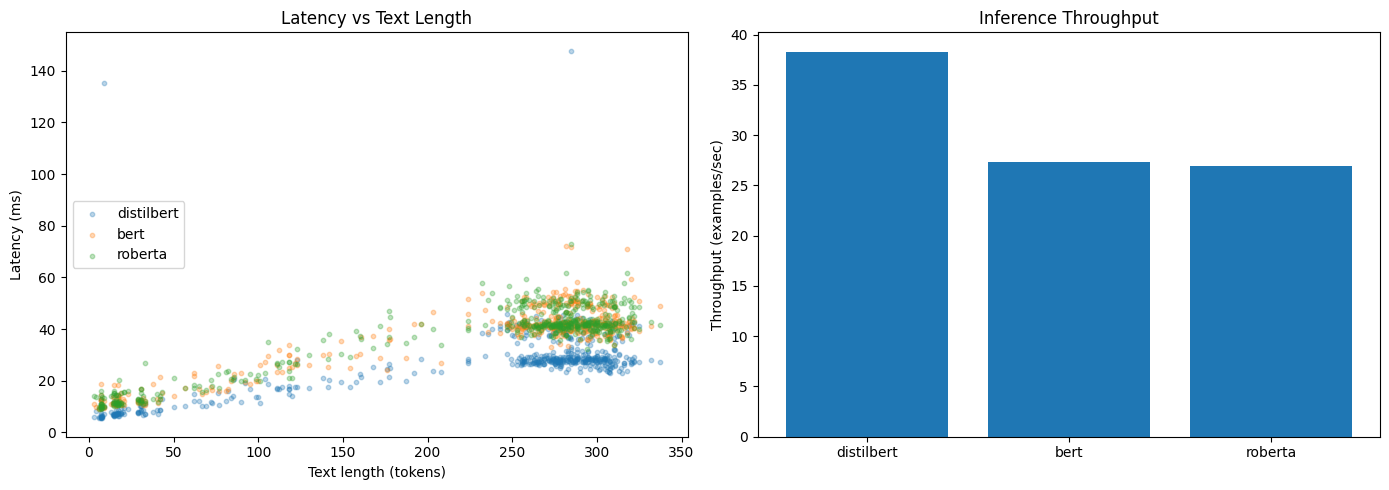

In [10]:
def find_model_path(model_key, seed=42):
    """Find the best saved model path for a given model key and seed."""
    candidates = [
        f"models/{model_key}_{seed}/best",
        f"models/{model_key}/best",
    ]
    for c in candidates:
        if Path(c).exists() and (Path(c) / "config.json").exists():
            return c
    # Fallback: find checkpoint dirs
    checkpoint_dirs = sorted(glob.glob(f"models/{model_key}_{seed}/checkpoint-*/config.json"))
    if checkpoint_dirs:
        return str(Path(checkpoint_dirs[-1]).parent)
    return None

def profile_latency(model_path, test_data, n=500):
    """Profile inference latency on n test examples."""
    ner = hf_pipeline("ner", model=model_path, tokenizer=model_path, aggregation_strategy="simple")
    latencies, lengths = [], []
    for ex in test_data[:n]:
        text = " ".join(ex["tokens"])
        start = time.perf_counter()
        ner(text)
        latencies.append(time.perf_counter() - start)
        lengths.append(len(ex["tokens"]))
    return np.array(latencies), np.array(lengths)

# Profile each model
latency_results = {}
for model_key in MODEL_CONFIGS:
    path = find_model_path(model_key)
    if path:
        print(f"Profiling {model_key} from {path}...")
        lats, lens = profile_latency(path, test_data, n=min(500, len(test_data)))
        latency_results[model_key] = {"latencies": lats, "lengths": lens}
        print(f"  P50={np.percentile(lats,50)*1000:.1f}ms  P95={np.percentile(lats,95)*1000:.1f}ms  P99={np.percentile(lats,99)*1000:.1f}ms")
    else:
        print(f"Skipping {model_key} — no saved model found")

# Plot latency vs text length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for mk, r in latency_results.items():
    axes[0].scatter(r["lengths"], r["latencies"]*1000, alpha=0.3, s=10, label=mk)
axes[0].set_xlabel("Text length (tokens)")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Latency vs Text Length")
axes[0].legend()

# Throughput bar chart
names = list(latency_results.keys())
throughputs = [len(r["latencies"])/r["latencies"].sum() for r in latency_results.values()]
axes[1].bar(names, throughputs)
axes[1].set_ylabel("Throughput (examples/sec)")
axes[1].set_title("Inference Throughput")
plt.tight_layout()
plt.show()

## Summary — Publish to Weave

Aggregate all results into a single summary dict and publish to Weave for tracking. This includes entity-level F1, cross-validation stats, multi-seed stats, and latency percentiles for all models.

In [11]:
summary = {
    "entity_level": {mk: {e: r.get(e, {}).get("f1-score", 0)
                          for e in ["NAME", "ADDRESS", "macro avg"]}
                     for mk, r in all_reports.items()},
    "cross_validation": {mk: {e: f"{m[e]['mean']:.4f}±{m[e]['std']:.4f}"
                               for e in m} for mk, m in cv_results.items()},
    "multi_seed": {mk: f"{r['mean']:.4f}±{r['std']:.4f}" for mk, r in seed_results.items()},
    "latency": {mk: {"p50_ms": float(np.percentile(r["latencies"], 50)*1000),
                      "p95_ms": float(np.percentile(r["latencies"], 95)*1000),
                      "p99_ms": float(np.percentile(r["latencies"], 99)*1000)}
                for mk, r in latency_results.items()},
}

weave.publish(summary, name="phi-ner-evaluation-results")
print("Published evaluation results to Weave.")
print(json.dumps(summary, indent=2))

weave: 📦 Published to https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave/objects/phi-ner-evaluation-results/versions/fHZxCGUsa6riYLUOKVSr6Q4BwYrgN6qeUfg63kJTJKo


Published evaluation results to Weave.
{
  "entity_level": {
    "distilbert": {
      "NAME": 1.0,
      "ADDRESS": 0.959409594095941,
      "macro avg": 0.9797047970479704
    },
    "bert": {
      "NAME": 1.0,
      "ADDRESS": 0.9593094944512947,
      "macro avg": 0.9796547472256474
    },
    "roberta": {
      "NAME": 1.0,
      "ADDRESS": 0.9644473173884939,
      "macro avg": 0.982223658694247
    }
  },
  "cross_validation": {
    "distilbert": {
      "NAME": "0.9998\u00b10.0004",
      "ADDRESS": "0.9657\u00b10.0084",
      "macro avg": "0.9827\u00b10.0043"
    },
    "bert": {
      "NAME": "0.9992\u00b10.0012",
      "ADDRESS": "0.9644\u00b10.0092",
      "macro avg": "0.9818\u00b10.0051"
    },
    "roberta": {
      "NAME": "0.9994\u00b10.0005",
      "ADDRESS": "0.9694\u00b10.0040",
      "macro avg": "0.9844\u00b10.0019"
    }
  },
  "multi_seed": {
    "distilbert": "0.9817\u00b10.0023",
    "bert": "0.9810\u00b10.0016",
    "roberta": "0.9799\u00b10.0022"
  },
  "la

In [12]:
# End Time
end_time = time.time()
total_time = end_time - start_time

# Convert to minutes and seconds
mins, secs = divmod(total_time, 60)
print(f"Total Notebook Execution Time: {int(mins)}m {int(secs)}s")

Total Notebook Execution Time: 283m 9s
